In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [6]:
logMmin = 13.0
logMmax = 13.1

odir1 = "../../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/sat_sum/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum_sat = pickle.load(f)

with open(f"{odir1}/snap40/mvir/logM_range/sat/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal_sat = pickle.load(f)


In [7]:
logMmin = 13.0
logMmax = 13.1

odir1 = "../../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)

with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)


In [298]:
logMmin = 13.0
logMmax = 13.1

odir1 = f"/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/number_density"
fname1 = f"{odir1}/sat_nfw_sum/logM_range/logM13.0-13.1/n200.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum_sat = pickle.load(f)
fname2 = f"{odir1}/sat_nfw/logM_range/logM13.0-13.1/c4_rvir0.5_n200.pickle"
with open(fname2, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal_sat = pickle.load(f)

In [299]:
logMmin = 13.0
logMmax = 13.1

odir1 = f"/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/weighted_nfw/logM{logMmin}-{logMmax}"
fname1 = f"{odir1}/sat_nfw_sum/weighted_c4_rvir0.5_n50/with_cent/cent_w20.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)
fname2 = f"{odir1}/sat_nfw/weighted_c4_rvir0.5_n50/with_cent/cent_w20.pickle"
with open(fname2, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)

In [300]:
logks_tng = np.log10(Pk13_sum["k"])

In [301]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [302]:
uk2_13 = compute_uk2(Pk13_gal, Pk13_sum)

In [303]:
uk2_13_sat = compute_uk2(Pk13_gal_sat, Pk13_sum_sat)

In [371]:
def gaussian(x, mu, sigma):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sigma) * np.exp(-np.power((x - mu) / sigma, 2.0) / 2)
    )

def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

def tot_profile(r, rho0, rs):
    y = ((50/70)*nfw_profile(r, rho0, rs))+((20/70)*gaussian(r, mu=0, sigma=0.001)*1e18)
    return y

In [372]:
def integrate_nfw(rho0, rs, rmax):
    integrand = lambda r: 4 * np.pi * r**2 * nfw_profile(r, rho0, rs)
    total_mass_nfw, _ = quad(integrand, 0, rmax)
    return total_mass_nfw

# Integrate the Gaussian to find its total mass
def integrate_gaussian(sigma, rmax):
    integrand = lambda r: 4 * np.pi * r**2 * gaussian(r, 0, sigma)
    total_mass_gaussian, _ = quad(integrand, 0, rmax)
    return total_mass_gaussian



total_mass_nfw = integrate_nfw(rho0, rs, 0.5)
total_mass_gaussian = integrate_gaussian(0.001, 0.5)

scaling_factor = total_mass_nfw / total_mass_gaussian

print(np.log10(scaling_factor))

18.201820131642318


(0.001, 1000)

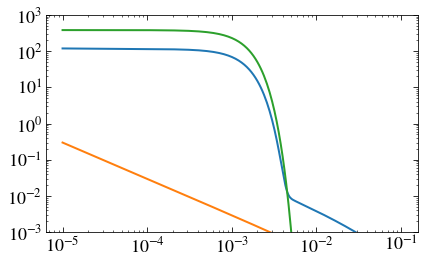

In [373]:
rs1 = np.arange(0.00001, 0.1, 0.0001)
plt.plot(rs1, tot_profile(rs1, rho0, rs)/1e18)
plt.plot(rs1, (1/21)*nfw_profile(rs1, rho0, rs)/1e18)
plt.plot(rs1, (20/21)*gaussian(rs1, mu=0, sigma=0.001))
plt.loglog()
plt.ylim(10**-3,10**3)

0.5235987755982988

[]

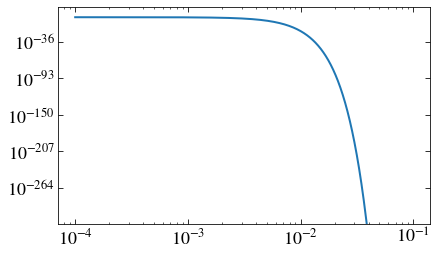

In [252]:
plt.plot(rs1, gaussian(rs1, mu=0, sigma=0.001))
plt.loglog()

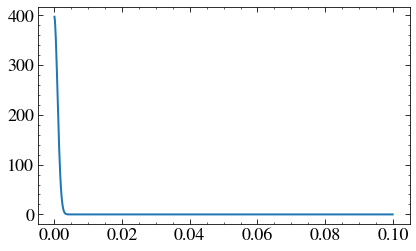

In [202]:
rs = np.arange(0.0001, 0.1, 0.0001)
plt.plot(rs, gaussian(rs, mu=0, sigma=0.001))

In [217]:
rvir = 0.5
c = 4
r_s = rvir/c
print(r_s)
rho0 = rho_s(10**13, r_s, c)
print(rho0)

0.125
503357512733780.2


In [264]:
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [374]:
def tot_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * tot_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * tot_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [375]:
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks

c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=0.5)

In [376]:
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks

c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical = tot_ft_numerical(ks, rho0, rs,rvir, rmax=0.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

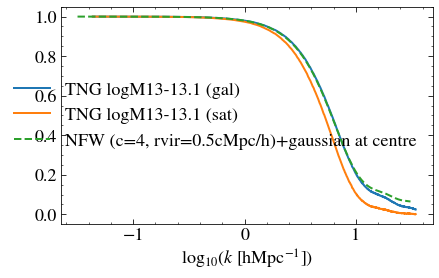

In [379]:
plt.plot(logks_tng, uk2_13, label="TNG logM13-13.1 (gal)")
plt.plot(logks_tng, uk2_13_sat, label="TNG logM13-13.1 (sat)")

plt.plot(logks, uk_numerical**2, label=f"NFW (c={c}, rvir={rvir}cMpc/h)+gaussian at centre", linestyle="dashed")

plt.legend()

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")